In [3]:
import zipfile
import tarfile
import os
import shutil

def extract_nested_datasets(zip_files, target_folder='paris_images'):
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
    
    for zip_path in zip_files:
        print(f"--- Procesando {zip_path} ---")
        
        # 1. Extraer el .tgz del .zip
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Extraemos en una carpeta temporal
            zip_ref.extractall('temp_tgz')
            
            # Buscamos el archivo .tgz que estaba adentro
            for file in os.listdir('temp_tgz'):
                if file.endswith('.tgz'):
                    tgz_path = os.path.join('temp_tgz', file)
                    print(f"Extraído {file}, ahora descomprimiendo imágenes...")
                    
                    # 2. Extraer las imágenes del .tgz
                    with tarfile.open(tgz_path, "r:gz") as tar:
                        tar.extractall(path=target_folder)
        
        # Limpiar carpeta temporal del tgz
        shutil.rmtree('temp_tgz')
        print(f"¡Listo! Imágenes de {zip_path} guardadas en '{target_folder}'.")

# Lista de tus archivos (asegúrate de que estén en la misma carpeta que el script)
mis_archivos = ['paris_1.tgz.zip', 'paris_2.tgz.zip']

# Ejecutar la extracción
extract_nested_datasets(mis_archivos)

--- Procesando paris_1.tgz.zip ---
Extraído paris_1.tgz, ahora descomprimiendo imágenes...
¡Listo! Imágenes de paris_1.tgz.zip guardadas en 'paris_images'.
--- Procesando paris_2.tgz.zip ---
Extraído paris_2.tgz, ahora descomprimiendo imágenes...
¡Listo! Imágenes de paris_2.tgz.zip guardadas en 'paris_images'.


In [6]:
import cv2
import numpy as np
import os
import glob
from tqdm import tqdm
import pickle # Para guardar los resultados y no tener que repetir el proceso

# --- CONFIGURACIÓN ---
BASE_PATH = 'paris_images/paris'
IMAGE_SIZE_HOG = (128, 128) # Tamaño fijo para HOG

# Inicializar SIFT
sift = cv2.SIFT_create(nfeatures=500) # Limitamos a 500 puntos para eficiencia

# Inicializar HOG
# Parámetros estándar para HOG
hog = cv2.HOGDescriptor(
    _winSize=IMAGE_SIZE_HOG,
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

# Listar todas las imágenes recursivamente
print("Buscando imágenes...")
image_files = glob.glob(os.path.join(BASE_PATH, "**", "*.jpg"), recursive=True)
print(f"Total de imágenes encontradas: {len(image_files)}")

# Diccionarios para almacenar las características
# { "ruta_imagen": caracteristicas }
sift_features = {}
hog_features = {}

print("Iniciando extracción de características (SIFT y HOG)...")

for path in tqdm(image_files):
    # 1. Cargar imagen
    img = cv2.imread(path)
    if img is None:
        continue
    
    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # --- EXTRACCIÓN SIFT (Local) ---
    # Detecta puntos clave y extrae descriptores (matriz de N x 128)
    kp, des_sift = sift.detectAndCompute(gray, None)
    if des_sift is not None:
        sift_features[path] = des_sift
    
    # --- EXTRACCIÓN HOG (Global/Estructural) ---
    # HOG requiere redimensionar la imagen a un tamaño fijo
    gray_resized = cv2.resize(gray, IMAGE_SIZE_HOG)
    # Calcula el vector HOG (vector plano)
    des_hog = hog.compute(gray_resized)
    # .flatten() asegura que sea un vector de una sola dimensión
    hog_features[path] = des_hog.flatten()

# --- GUARDAR RESULTADOS ---
# Guardamos en archivos .pkl para que puedas cargarlos en otro script sin procesar todo de nuevo
print("Guardando características en archivos .pkl...")

with open('sift_features.pkl', 'wb') as f:
    pickle.dump(sift_features, f)

with open('hog_features.pkl', 'wb') as f:
    pickle.dump(hog_features, f)

print("¡Extracción completada con éxito!")
print(f"SIFT extraído de: {len(sift_features)} imágenes")
print(f"HOG extraído de: {len(hog_features)} imágenes")

Buscando imágenes...
Total de imágenes encontradas: 6412
Iniciando extracción de características (SIFT y HOG)...


100%|██████████| 6412/6412 [28:21<00:00,  3.77it/s]


Guardando características en archivos .pkl...
¡Extracción completada con éxito!
SIFT extraído de: 6392 imágenes
HOG extraído de: 6392 imágenes


Cargando descriptores SIFT...
Preparando muestra para K-Means...
Entrenando K-Means con K=100 (Esto puede tardar un poco)...


c:\Users\RyanO\anaconda3\envs\Vision\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Generando histogramas (Bag of Visual Words)...
Ploteando histogramas de ejemplo...


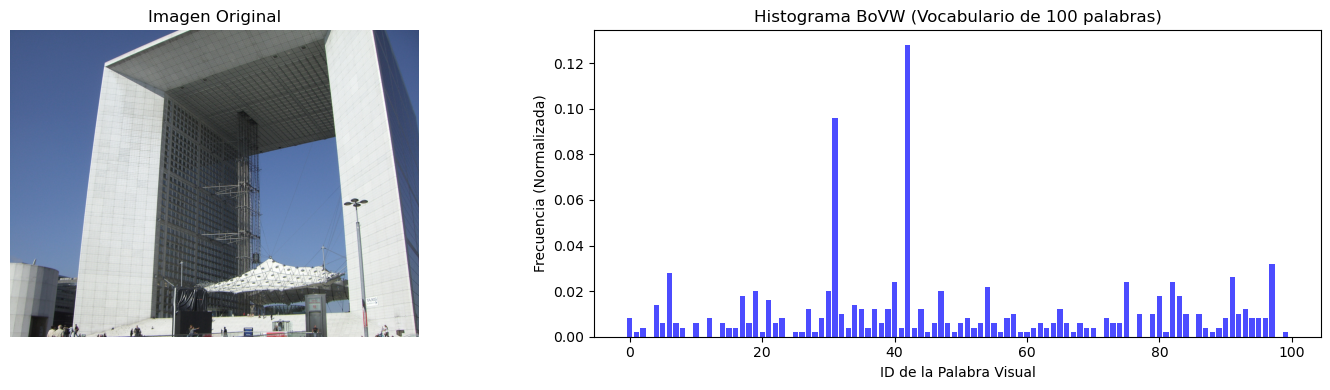

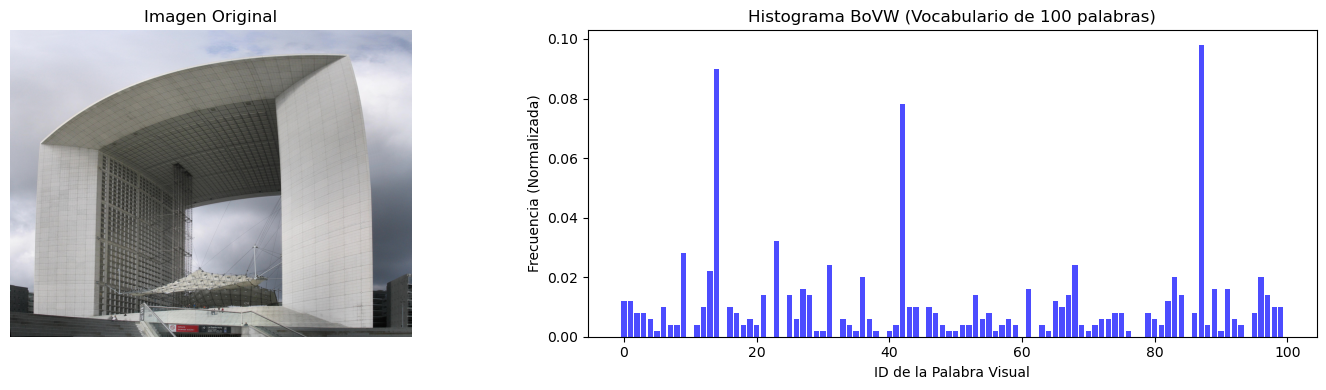

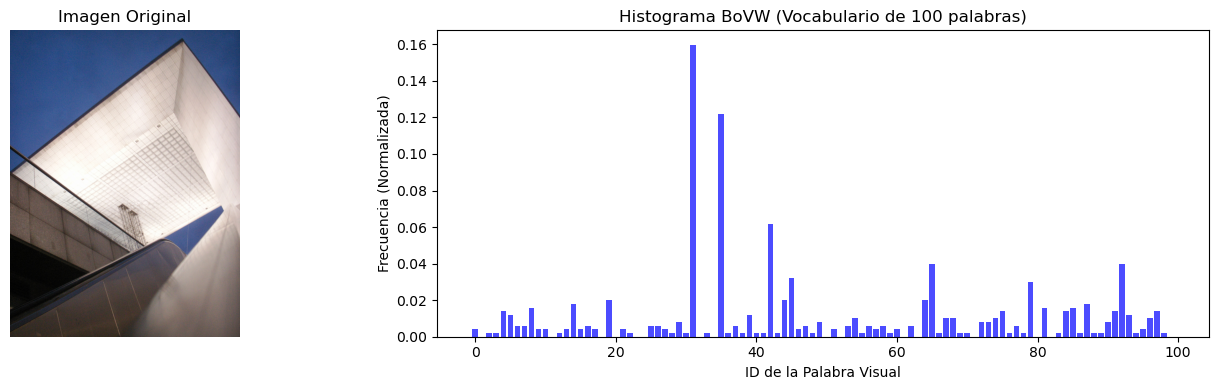

In [10]:
import pickle
import numpy as np
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

# 1. CARGAR LAS CARACTERÍSTICAS SIFT QUE GUARDAMOS ANTES
print("Cargando descriptores SIFT...")
with open('sift_features.pkl', 'rb') as f:
    sift_features = pickle.load(f)

# 2. PREPARAR DATOS PARA K-MEANS
# Para crear el vocabulario, necesitamos una "pila" gigante de descriptores
print("Preparando muestra para K-Means...")
all_des_list = list(sift_features.values())

# Usamos una muestra (ej. cada 10 descriptores) para no saturar la RAM
# pero que sea representativa de todo el dataset
descriptors_stack = np.vstack([d for d in all_des_list if d is not None])
descriptors_sample = descriptors_stack[::10] 

# 3. ENTRENAR K-MEANS (CONSTRUIR EL VOCABULARIO)
K = 100  # Justificación: Un vocabulario de 500 es balanceado para ~6000 imágenes
print(f"Entrenando K-Means con K={K} (Esto puede tardar un poco)...")
kmeans = MiniBatchKMeans(n_clusters=K, n_init=3, random_state=42, batch_size=1000)
kmeans.fit(descriptors_sample)

# 4. REPRESENTAR CADA IMAGEN COMO UN HISTOGRAMA (CUANTIFICACIÓN)
print("Generando histogramas (Bag of Visual Words)...")

def build_histogram(descriptors, kmeans_model, k_size):
    # Cada descriptor se asigna a la 'palabra visual' (cluster) más cercana
    visual_words = kmeans_model.predict(descriptors)
    # Contamos cuántas veces aparece cada palabra
    hist, _ = np.histogram(visual_words, bins=range(k_size + 1), density=True)
    return hist

# Diccionario para guardar los histogramas
bovw_histograms = {}
for path, des in sift_features.items():
    if des is not None:
        bovw_histograms[path] = build_histogram(des, kmeans, K)

# 5. VISUALIZAR LOS HISTOGRAMAS
print("Ploteando histogramas de ejemplo...")

def plot_image_and_hist(img_path, histogram):
    img = plt.imread(img_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    # Mostrar Imagen
    ax1.imshow(img)
    ax1.set_title("Imagen Original")
    ax1.axis('off')
    
    # Mostrar Histograma (Bag of Visual Words)
    ax2.bar(range(len(histogram)), histogram, color='blue', alpha=0.7)
    ax2.set_title(f"Histograma BoVW (Vocabulario de {K} palabras)")
    ax2.set_xlabel("ID de la Palabra Visual")
    ax2.set_ylabel("Frecuencia (Normalizada)")
    
    plt.tight_layout()
    plt.show()

# Graficar las primeras 3 imágenes del dataset
ejemplos = list(bovw_histograms.keys())[:3]
for p in ejemplos:
    plot_image_and_hist(p, bovw_histograms[p])

# Guardar los histogramas para el paso de recuperación final
with open('bovw_histograms.pkl', 'wb') as f:
    pickle.dump(bovw_histograms, f)

### Experimentación con K's

Iniciando experimentación de tamaños de vocabulario...

--- Probando K = 100 ---


c:\Users\RyanO\anaconda3\envs\Vision\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Precision@5 para K=100: 0.4700

--- Probando K = 500 ---


c:\Users\RyanO\anaconda3\envs\Vision\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Precision@5 para K=500: 0.4000

--- Probando K = 1000 ---


c:\Users\RyanO\anaconda3\envs\Vision\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Precision@5 para K=1000: 0.3000

--- Probando K = 2000 ---


c:\Users\RyanO\anaconda3\envs\Vision\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Precision@5 para K=2000: 0.3600


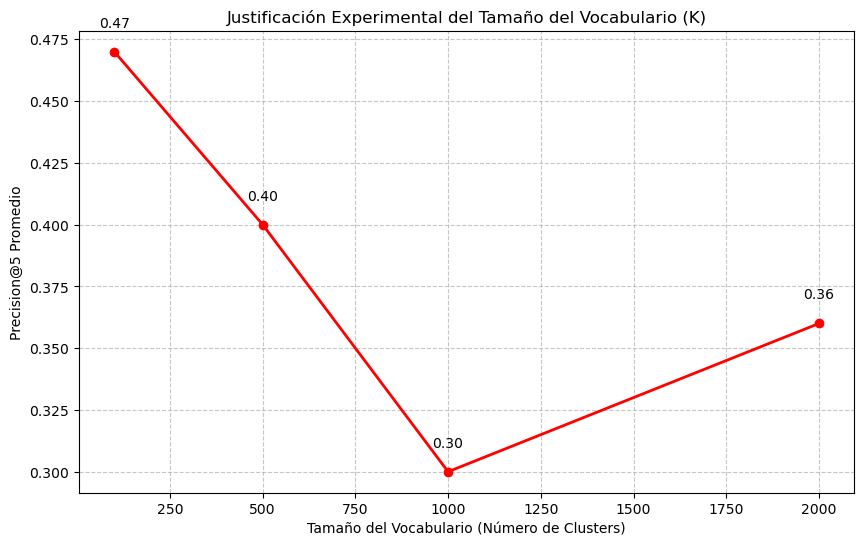

In [8]:
import pickle
import numpy as np
import os
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. CARGAR DATOS
with open('sift_features.pkl', 'rb') as f:
    sift_features = pickle.load(f)

# Extraer etiquetas (nombres de carpetas) para evaluación
# Ejemplo: 'paris_images/paris/eiffel/img1.jpg' -> label: 'eiffel'
image_paths = list(sift_features.keys())
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

# 2. DEFINIR VALORES DE K A PROBAR
k_values = [100, 500, 1000, 2000]
results_precision = []

# Muestra de descriptores para entrenar K-Means
all_des = np.vstack([d for d in sift_features.values() if d is not None])[::15]

print("Iniciando experimentación de tamaños de vocabulario...")

for k in k_values:
    print(f"\n--- Probando K = {k} ---")
    
    # A. Entrenar K-Means
    kmeans = MiniBatchKMeans(n_clusters=k, n_init=3, random_state=42)
    kmeans.fit(all_des)
    
    # B. Generar Histogramas para todas las imágenes
    hists = []
    for p in image_paths:
        des = sift_features[p]
        v_words = kmeans.predict(des)
        h, _ = np.histogram(v_words, bins=range(k + 1), density=True)
        hists.append(h)
    hists = np.array(hists)
    
    # C. Evaluar: Precision@5 promedio
    # Tomamos 20 imágenes al azar como 'queries' para testear este K
    test_indices = np.random.choice(len(image_paths), 20, replace=False)
    precisions = []
    
    for idx in test_indices:
        query_hist = hists[idx].reshape(1, -1)
        query_label = labels[idx]
        
        # Calcular similitud contra todos
        sims = cosine_similarity(query_hist, hists).flatten()
        # Obtener los 6 mejores (el 1ro es la misma imagen, lo quitamos)
        best_idx = np.argsort(sims)[::-1][1:6]
        
        # Calcular cuántos de los top 5 tienen la misma etiqueta
        hits = sum([1 for i in best_idx if labels[i] == query_label])
        precisions.append(hits / 5.0)
    
    avg_p = np.mean(precisions)
    results_precision.append(avg_p)
    print(f"Precision@5 para K={k}: {avg_p:.4f}")

# 3. GRAFICAR RESULTADOS PARA EL INFORME
plt.figure(figsize=(10, 6))
plt.plot(k_values, results_precision, marker='o', linestyle='-', color='red', linewidth=2)
plt.title("Justificación Experimental del Tamaño del Vocabulario (K)")
plt.xlabel("Tamaño del Vocabulario (Número de Clusters)")
plt.ylabel("Precision@5 Promedio")
plt.grid(True, linestyle='--', alpha=0.7)

# Añadir etiquetas de texto sobre los puntos
for i, val in enumerate(results_precision):
    plt.text(k_values[i], val + 0.01, f"{val:.2f}", ha='center')

plt.show()

Generando vectores combinados para toda la base de datos...


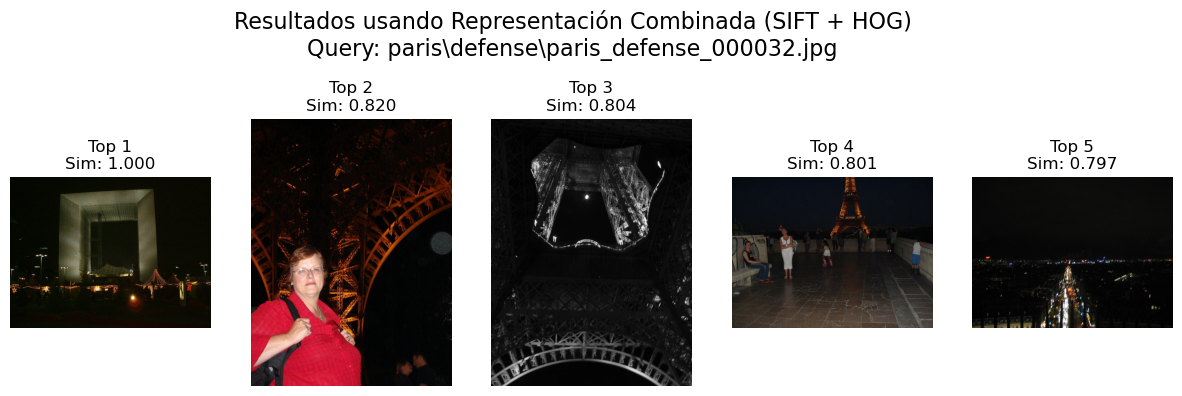

In [13]:
import numpy as np
import cv2
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN Y CARGA DE DATOS ---
# Asumimos que ya tienes 'bovw_histograms' (K=100) y 'hog_features' de los pasos anteriores
with open('bovw_histograms.pkl', 'rb') as f:
    bovw_db = pickle.load(f)  # Diccionario {path: hist}

with open('hog_features.pkl', 'rb') as f:
    hog_db = pickle.load(f)   # Diccionario {path: feat}

image_paths = list(bovw_db.keys())

# --- 2. FUNCIÓN PARA CREAR EL VECTOR COMBINADO ---
def get_combined_vector(bovw_feat, hog_feat):
    """
    Normaliza y concatena dos tipos de descriptores.
    """
    # Normalización L2: Asegura que ambos vectores tengan el mismo 'peso' 
    # y que la suma de sus cuadrados sea 1.
    bovw_norm = bovw_feat / (np.linalg.norm(bovw_feat) + 1e-7)
    hog_norm = hog_feat / (np.linalg.norm(hog_feat) + 1e-7)
    
    # Concatenación: Unimos los dos vectores horizontalmente
    return np.hstack([bovw_norm, hog_norm])

# --- 3. CREAR LA BASE DE DATOS COMBINADA ---
print("Generando vectores combinados para toda la base de datos...")
combined_db = []
for path in image_paths:
    combined_vec = get_combined_vector(bovw_db[path], hog_db[path])
    combined_db.append(combined_vec)

combined_db = np.array(combined_db)

# --- 4. FUNCIÓN DE BÚSQUEDA PARA COMPARAR MÉTODOS ---
def buscar_y_comparar(query_path):
    # Obtener features de la query
    q_bovw = bovw_db[query_path]
    q_hog = hog_db[query_path]
    q_combined = get_combined_vector(q_bovw, q_hog).reshape(1, -1)
    
    # Similitud de Coseno en la base de datos combinada
    sims = cosine_similarity(q_combined, combined_db).flatten()
    top_5_idx = np.argsort(sims)[::-1][:5]
    
    # Graficar resultados
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Resultados usando Representación Combinada (SIFT + HOG)\nQuery: {query_path.split('/')[-1]}", fontsize=16)
    
    for i, idx in enumerate(top_5_idx):
        img_res = cv2.imread(image_paths[idx])
        img_res = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i+1)
        plt.imshow(img_res)
        plt.title(f"Top {i+1}\nSim: {sims[idx]:.3f}")
        plt.axis('off')
    plt.show()

# --- 5. EJECUCIÓN ---
# Probamos con una imagen de la base de datos
query_ejemplo = image_paths[20] 
buscar_y_comparar(query_ejemplo)

### Vemos que ha fallado xd

### Probaremos con LBP ahora :D

In [18]:
import cv2
import numpy as np
import os
import pickle
import glob
from skimage import feature
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. CONFIGURACIÓN DE RUTAS ---
BASE_PATH = 'paris_images/paris'
SIFT_PKL = 'sift_features.pkl'
HOG_PKL = 'hog_features.pkl'
LBP_PKL = 'lbp_features.pkl'
BOVW_PKL = 'bovw_histograms.pkl' # histogramas K=100

# --- 2. FUNCIÓN DE EXTRACCIÓN LBP ---
def extract_lbp_single(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (256, 256))
    
    # Parámetros: P=24 puntos, R=3 radio (captura textura fina y media)
    lbp = feature.local_binary_pattern(gray, 24, 3, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7) # Normalización interna
    return hist

# --- 3. PROCESAMIENTO Y GUARDADO ---
image_files = glob.glob(os.path.join(BASE_PATH, "**", "*.jpg"), recursive=True)

if not os.path.exists(LBP_PKL):
    print("Extrayendo LBP de todas las imágenes...")
    lbp_features = {}
    for path in tqdm(image_files):
        feat = extract_lbp_single(path)
        if feat is not None: lbp_features[path] = feat
    
    with open(LBP_PKL, 'wb') as f:
        pickle.dump(lbp_features, f)
    print(f"LBP guardado en {LBP_PKL}")
else:
    print("Cargando LBP desde archivo...")
    with open(LBP_PKL, 'rb') as f: lbp_features = pickle.load(f)

# Cargar los otros descriptores
with open(HOG_PKL, 'rb') as f: hog_features = pickle.load(f)
with open(BOVW_PKL, 'rb') as f: bovw_histograms = pickle.load(f)

# --- 4. CONSTRUCCIÓN DEL SUPER VECTOR ---
def get_super_vector(path):
    # Obtener los 3 vectores
    v_sift = bovw_histograms[path]
    v_hog = hog_features[path]
    v_lbp = lbp_features[path]
    
    # Normalización L2 Individual (crucial para que tengan el mismo peso)
    n_sift = v_sift / (np.linalg.norm(v_sift) + 1e-7)
    n_hog = v_hog / (np.linalg.norm(v_hog) + 1e-7)
    n_lbp = v_lbp / (np.linalg.norm(v_lbp) + 1e-7)
    
    # Concatenación: Fusión de características
    return np.hstack([n_sift, n_hog, n_lbp])

print("Construyendo base de datos con Super Vectores...")
valid_paths = list(bovw_histograms.keys())
super_db = np.array([get_super_vector(p) for p in valid_paths])

# --- 5. BÚSQUEDA Y EVALUACIÓN DEL CASO DE FALLA ---
def test_improved_search(query_path):
    # 1. Preparar Query
    q_vec = get_super_vector(query_path).reshape(1, -1)
    
    # 2. Similitud de Coseno
    sims = cosine_similarity(q_super, super_db).flatten()
    
    # 3. Top 5
    indices = np.argsort(sims)[::-1][:5]
    
    # 4. Visualización
    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Búsqueda con SUPER VECTOR (SIFT + HOG + LBP)\nQuery: {os.path.basename(query_path)}", fontsize=15)
    
    for i, idx in enumerate(indices):
        img_res = cv2.cvtColor(cv2.imread(valid_paths[idx]), cv2.COLOR_BGR2RGB)
        plt.subplot(1, 5, i+1)
        plt.imshow(img_res)
        plt.title(f"Top {i+1}\nSim: {sims[idx]:.3f}")
        plt.axis('off')
    plt.show()

# INTENTO CON LA DÉFENSE (ajusta la ruta exacta a tu archivo)
query_defensa = 'paris_images\paris\defense\paris_defense_000032.jpg'
if os.path.exists(query_defensa):
    test_improved_search(query_defensa)
else:
    print(f"No se encontró la imagen query en: {query_defensa}")

Cargando LBP desde archivo...
Construyendo base de datos con Super Vectores...


KeyError: 'paris_images\\paris\\defense\\paris_defense_000032.jpg'